In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler


# ==========================================
# STEP 1: LOAD DATASET
# ==========================================

df = pd.read_csv("Delivery_Logistics.csv")

print("Dataset loaded successfully!")

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset loaded successfully!

First 5 Rows:
   delivery_id delivery_partner      package_type vehicle_type delivery_mode  \
0       250.99        delhivery  automobile parts         bike      same day   
1       250.99       xpressbees         cosmetics       ev van       express   
2       250.99        shadowfax         groceries        truck       two day   
3       250.99              dhl       electronics       ev van      same day   
4       250.99              dhl          clothing          van       two day   

    region weather_condition  distance_km  package_weight_kg  \
0     west             clear        297.0              46.96   
1  central              cold         89.6              47.39   
2     east             rainy        273.5              26.89   
3     east              cold        269.7              12.69   
4    north             foggy        256.7              37.02   

             delivery_time_hours            expected_time_hours delayed  \
0  1970-01-01 0

In [36]:

df["delivery_time_hours"] = pd.to_datetime(
    df["delivery_time_hours"]
).dt.nanosecond

df["expected_time_hours"] = pd.to_datetime(
    df["expected_time_hours"]
).dt.nanosecond

print("\nDelivery Time After Conversion:")
print(df["delivery_time_hours"].head(20))

print("\nExpected Time After Conversion:")
print(df["expected_time_hours"].head(20))


Delivery Time After Conversion:
0      8
1      2
2     10
3      6
4      9
5      4
6      6
7      4
8      5
9      3
10     5
11     3
12     8
13     6
14    12
15     8
16    10
17    11
18     4
19     7
Name: delivery_time_hours, dtype: int32

Expected Time After Conversion:
0      8
1      3
2     16
3      8
4     16
5      2
6      8
7      8
8      8
9      8
10     8
11    16
12    16
13     2
14    16
15     6
16    24
17    24
18     8
19     3
Name: expected_time_hours, dtype: int32


In [37]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
delivery_id            0
delivery_partner       0
package_type           0
vehicle_type           0
delivery_mode          0
region                 0
weather_condition      0
distance_km            0
package_weight_kg      0
delivery_time_hours    0
expected_time_hours    0
delayed                0
delivery_status        0
delivery_rating        0
delivery_cost          0
dtype: int64


In [38]:
numeric_columns = df.select_dtypes(include=np.number).columns

print("\nNumerical Columns:")
print(numeric_columns.tolist())


Numerical Columns:
['delivery_id', 'distance_km', 'package_weight_kg', 'delivery_time_hours', 'expected_time_hours', 'delivery_rating', 'delivery_cost']


In [39]:
Q1 = df["distance_km"].quantile(0.25)
Q3 = df["distance_km"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["distance_km"] < lower_bound) |
    (df["distance_km"] > upper_bound)
]

print("\nDistance Outlier Analysis:")
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(outliers))


Distance Outlier Analysis:
Q1: 75.9
Q3: 224.9
IQR: 149.0
Lower Bound: -147.6
Upper Bound: 448.4
Number of Outliers: 0


Text(0, 0.5, 'Distance (km)')

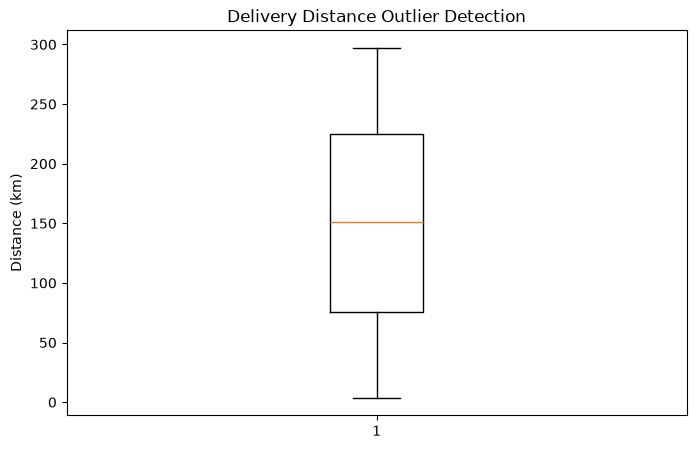

In [40]:
plt.figure(figsize=(8, 5))

plt.boxplot(df["distance_km"])

plt.title("Delivery Distance Outlier Detection")
plt.ylabel("Distance (km)")

In [41]:
columns_to_normalize = [
    "distance_km",
    "package_weight_kg",
    "delivery_time_hours",
    "expected_time_hours",
    "delivery_rating",
    "delivery_cost"
]

scaler = MinMaxScaler()

df[columns_to_normalize] = scaler.fit_transform(
    df[columns_to_normalize]
)

print("\nNormalization completed successfully!")

print("\nNormalized Numerical Data:")
print(df[columns_to_normalize].describe())


Normalization completed successfully!

Normalized Numerical Data:
        distance_km  package_weight_kg  delivery_time_hours  \
count  25000.000000       25000.000000         25000.000000   
mean       0.500138           0.501042             0.328844   
std        0.294411           0.294138             0.165312   
min        0.000000           0.000000             0.000000   
25%        0.246337           0.245855             0.210526   
50%        0.502215           0.501024             0.315789   
75%        0.754003           0.757216             0.421053   
max        1.000000           1.000000             1.000000   

       expected_time_hours  delivery_rating  delivery_cost  
count         25000.000000     25000.000000   25000.000000  
mean              0.504895         0.666500       0.500488  
std               0.343592         0.287491       0.283473  
min               0.000000         0.000000       0.000000  
25%               0.272727         0.500000       0.257072  

In [42]:
categorical_columns = df.select_dtypes(
    include="object"
).columns

print("\nCategorical Columns:")
print(categorical_columns.tolist())

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

print("\nCategorical encoding completed successfully!")



Categorical Columns:
['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'delayed', 'delivery_status']

Categorical encoding completed successfully!


In [43]:
print("\nFinal Dataset Shape:")
print(df.shape)

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

print("\nFinal Dataset Preview:")
print(df.head())


Final Dataset Shape:
(25000, 43)

Total Missing Values:
0

Final Dataset Preview:
   delivery_id  distance_km  package_weight_kg  delivery_time_hours  \
0       250.99     0.999659           0.947595             0.421053   
1       250.99     0.293015           0.956397             0.105263   
2       250.99     0.919591           0.536745             0.526316   
3       250.99     0.906644           0.246059             0.315789   
4       250.99     0.862351           0.744115             0.473684   

   expected_time_hours  delivery_rating  delivery_cost  \
0             0.272727             0.50       1.000000   
1             0.045455             1.00       0.354251   
2             0.636364             0.75       0.879932   
3             0.272727             0.50       0.904915   
4             0.636364             0.75       0.845054   

   delivery_partner_blue dart  delivery_partner_delhivery  \
0                       False                        True   
1                  

In [44]:
df.to_csv(
    "cleaned_logistics_dataset.csv",
    index=False
)

print("\nCleaned dataset saved successfully!")


Cleaned dataset saved successfully!
